In [1]:

import sys
from pathlib import Path

repo = Path.cwd()
sys.path.insert(0, str(repo / "src"))

import bpy
print(bpy.app.version_string)

5.0.1


In [2]:
from scene.render_offline import (
    render_still,
    render_camera_motion_sequence,
    frames_to_gif,
    frames_to_events_npy_and_gif,
)

from IPython.display import Image, display

In [3]:
object_path = repo / "data" / "airplane_010.blend"

output_root = repo / "data" / "renders" / "airplane_demo"
still_path = output_root / "still_test.png"
sequence_dir = output_root / "motion_sequence"
video_path = sequence_dir / "rgb_motion.mp4"

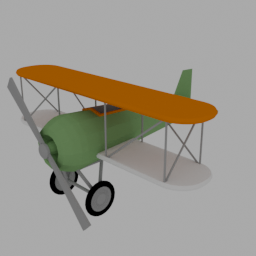

In [4]:
result = render_still(
    object_path=object_path,
    output_path=still_path,
    resolution=256,
    samples=128,
    use_gpu=True,

    object_target_size=0.45,
    object_azimuth_deg=315.0,
    object_elevation_deg=30.0,

    camera_position=(0.0, -0.25, 1.5),
    camera_target=(0.0, 0.0, 0.0),
    focal_length=50.0,
    sensor_width_mm=32.0,

    light_location=(0.0, 0.0, 5.0),
    light_size=10.0,
    light_strength=50.0,
)

display(Image(filename=str(still_path)))

In [5]:
seq = render_camera_motion_sequence(
    object_path=object_path,
    output_dir=sequence_dir,

    # video length
    num_frames=120,
    fps=60,

    # same render/image setup as still
    resolution=256,
    samples=128,
    use_gpu=True,

    # same object setup as still
    object_target_size=0.45,
    object_azimuth_deg=315.0,
    object_elevation_deg=30.0,

    # same camera setup as still
    camera_position=(0.0, -0.25, 1.5),
    camera_target=(0.0, 0.0, 0.0),
    focal_length=50.0,
    sensor_width_mm=32.0,

    # same light setup as still
    light_location=(0.0, 0.0, 5.0),
    light_size=10.0,
    light_strength=50.0,

    # camera motion
    drift_sigma_deg=(0.003, 0.003),
    microsaccade_rate_hz=5.0,
    microsaccade_amp_deg=(0.05, 0.25),
    microsaccade_dur_ms=(10, 25),
    jitter_sigma_deg=(0.005, 0.005),

    seed=0,
)

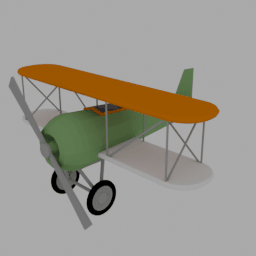

In [6]:
gif_path = sequence_dir / "rgb_motion.gif"

gif_file = frames_to_gif(
    frames_dir=seq["frames_dir"],
    output_gif=gif_path,
    fps=30,
    loop=0,
)

display(Image(filename=str(gif_path)))

In [7]:
ev = frames_to_events_npy_and_gif(
    frames_dir=seq["frames_dir"],
    output_dir=sequence_dir / "events",
    fps=60,

    th_pos=0.15,
    th_neg=0.15,
    th_noise=0.05,
    lat=500,
    tau=300,
    jit=100,
    bgnp=0.0001,
    bgnn=0.0001,
    ref=40,

    skip_frames=0,

    gif_fps=20,
    gif_window_us=None,
    loop=0,
    timestamp_text=True,
    keep_dat=True,
)

display(Image(filename=ev["gif_path"]))

print("events.npy:", ev["npy_path"])
print("events.gif:", ev["gif_path"])
print("events.dat:", ev["dat_path"])

ModuleNotFoundError: No module named 'event_buffer'